<a href="https://colab.research.google.com/github/Kushagra524/LeetCode-DSA/blob/main/Leetcode_349.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

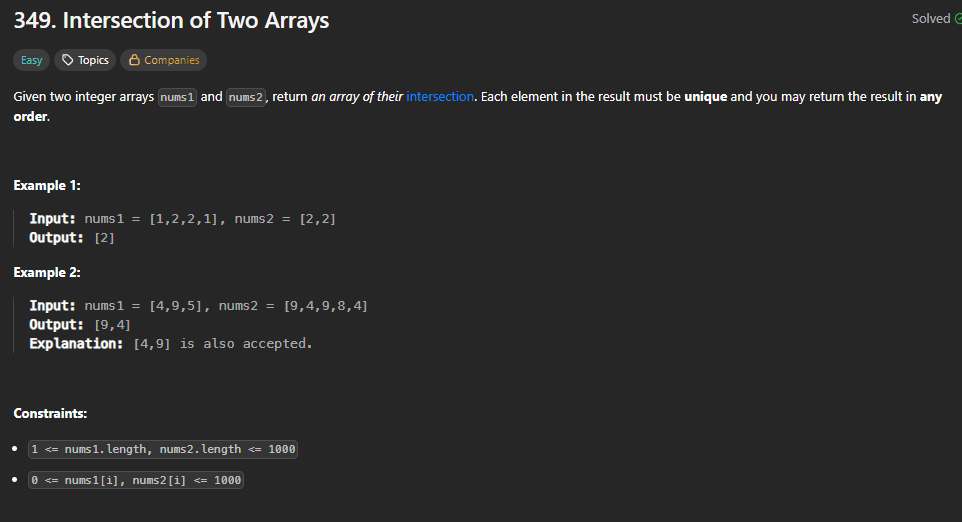

In [1]:
from typing import List

class Solution:
  def intersection(self , nums1 : List[int] , nums2 : List[int]) -> List[int]:
    s1 = set(nums1)
    s2 = set(nums2)
    s = s1 & s2      # & operator in set returns the common elements of both sets , we can also use .intersection() method for

    return list(s)

sol = Solution()

In [2]:
print(sol.intersection(nums1 = [1 , 2 , 2 , 1] , nums2 = [2 , 3 , 4 , 4]))

[2]


### Time and Space Complexity Analysis of the Original Set-Based Approach

Your initial approach uses Python's `set` data structure, which provides highly efficient operations for membership testing and intersection.

Let `n` be the length of `nums1` and `m` be the length of `nums2`.

#### Time Complexity
1.  **Converting to sets (`s1 = set(nums1)` and `s2 = set(nums2)`):** On average, converting a list to a set takes `O(L)` time, where `L` is the length of the list. So, this step takes `O(n + m)` time.
2.  **Set intersection (`s = s1 & s2`):** The `&` operator (or `.intersection()` method) for sets takes `O(min(len(s1), len(s2)))` time on average. In the worst case, this is `O(min(n, m))`.
3.  **Converting back to list (`return list(s)`):** Converting a set of `k` elements to a list takes `O(k)` time. In the worst case, `k` can be `min(n, m)`.

Combining these, the overall average time complexity is **`O(n + m)`**.

#### Space Complexity
1.  **Storing `s1`:** The set `s1` will store unique elements from `nums1`, requiring `O(n)` space in the worst case (if all elements are unique).
2.  **Storing `s2`:** Similarly, `s2` will require `O(m)` space in the worst case.
3.  **Storing `s` (the intersection):** The intersection set `s` will store up to `min(n, m)` unique common elements, requiring `O(min(n, m))` space.

Therefore, the overall space complexity is **`O(n + m)`** in the worst case, as it needs to store both initial sets.

### Implementation of Two Pointers with Sorted Arrays

This method sorts both input arrays and then uses two pointers to efficiently find common elements. Duplicate elements in the result are avoided by checking if the last added element is different from the current common element.

In [5]:
from typing import List

class SolutionTwoPointers:
  def intersection(self , nums1 : List[int] , nums2 : List[int]) -> List[int]:
    # Sort both arrays
    nums1.sort()
    nums2.sort()

    result = []
    i = 0  # Pointer for nums1
    j = 0  # Pointer for nums2

    while i < len(nums1) and j < len(nums2):
      if nums1[i] == nums2[j]:

        if not result or result[-1] != nums1[i]:
          result.append(nums1[i])
        i += 1
        j += 1

      elif nums1[i] < nums2[j]:
        i += 1

      else:
        j += 1

    return result

sol2 = SolutionTwoPointers()

### Demonstration of Two-Pointer Approach

In [7]:
print(sol2.intersection(nums1 = [1 , 2 , 2 , 1] , nums2 = [2 , 3 , 4 , 4]))
print(sol2.intersection(nums1 = [4, 9, 5] , nums2 = [9, 4, 9, 8, 4]))

[2]
[4, 9]


### Time and Space Complexity Analysis

#### Time Complexity
The dominant factor in the time complexity of this approach is the sorting step.

1.  **Sorting:** If `n` is the length of `nums1` and `m` is the length of `nums2`, sorting `nums1` takes `O(n log n)` time and sorting `nums2` takes `O(m log m)` time. Thus, the total time for sorting is `O(n log n + m log m)`.
2.  **Two-Pointer Iteration:** After sorting, the two pointers traverse each array at most once. In the worst case, both pointers might move through all elements of both arrays. This step takes `O(n + m)` time.

Combining these, the overall time complexity is **`O(n log n + m log m)`** due to the sorting step being more expensive than the linear scan.

#### Space Complexity
The space complexity depends on the sorting algorithm used and the space required for the result list.

1.  **Sorting:** Most built-in sorting algorithms (like Python's `sort()` method or `sorted()` function, which use Timsort) require `O(log k)` to `O(k)` space in the worst case, where `k` is the size of the list being sorted. If the sort is in-place, it's `O(log k)` or `O(1)` for some implementations, but generally `O(k)` auxiliary space is reasonable to consider for robust sorting.
2.  **Result List:** In the worst case, if all elements are common, the `result` list can store up to `min(n, m)` unique elements. So, this requires `O(min(n, m))` space.

Therefore, the overall space complexity is **`O(n + m)`** in the worst case, considering the space used by the sorting algorithm and the result list.